# py-hoodscanR tutorial — CosMx lung cancer

A Python-only walkthrough of every public function, on real data: a 2661-cell
subset of a NanoString CosMx SMI non-small-cell lung cancer section
(`Lung9_Rep1`), the dataset the upstream hoodscanR package ships.

**What the method does.** For each cell it finds the *k* nearest cells,
converts their distances into a probability distribution with a
temperature-scaled softmax, and collapses that onto the cell-type labels. The
result is, per cell, a genuine probability vector over "neighbourhood types" —
so its **entropy** (and its exponential, **perplexity**) tells you how mixed
that cell's surroundings are.

Contents:

1. `load_spe_test` / `read_hood_data` — getting data in
2. `find_near_cells` — the k-nearest-cell search
3. `scan_hoods` — the distance-weighted softmax (and the bandwidth τ)
4. `merge_by_group` — collapsing onto cell types (hard and fuzzy labels)
5. `merge_hood_adata` — writing results back
6. `calc_metrics` — entropy and perplexity
7. `perplexity_permute` — is this neighbourhood unusually distinct?
8. `clust_by_hood` — neighbourhood-based clustering
9. `plot_tissue`, `plot_hood_mat`, `plot_prob_dist`, `plot_colocal`
10. The `HoodScanR` class API
11. Pitfalls


In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
import pyhoodscanr as ph

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
print('py-hoodscanR', ph.__version__)

py-hoodscanR 0.1.0


## 1. Getting data in

`load_spe_test()` returns the bundled fixture. For your own data you need an
`AnnData` with coordinates in `.obsm['spatial']` and a cell-type column in
`.obs`; `read_hood_data` normalises it (it is the analogue of R's
`readHoodData`, which takes a `SpatialExperiment`).

In [2]:
adata = ph.load_spe_test()
adata = ph.read_hood_data(adata, anno_col='cell_annotation')
print(adata)
adata.obs['cell_annotation'].value_counts()

AnnData object with n_obs × n_vars = 2661 × 1
    obs: 'cell_annotation'
    obsm: 'spatial'


cell_annotation
Tumor.cells         1156
Dividing.cells       630
Stromal              488
Epithelial.cell      274
Immune.cell           60
Endothelial.cell      53
Name: count, dtype: int64

In [3]:
# From plain data frames instead (R's cell_pos_dat / cell_anno_dat path)
pos = pd.DataFrame({'cell_id': adata.obs_names,
                    'x': adata.obsm['spatial'][:, 0],
                    'y': adata.obsm['spatial'][:, 1]})
ann = pd.DataFrame({'cell_id': adata.obs_names,
                    'ct': adata.obs['cell_annotation'].to_numpy()})
ph.read_hood_data(cell_pos_dat=pos, cell_anno_dat=ann)

AnnData object with n_obs × n_vars = 2661 × 10
    obs: 'cell_annotation'
    obsm: 'spatial'

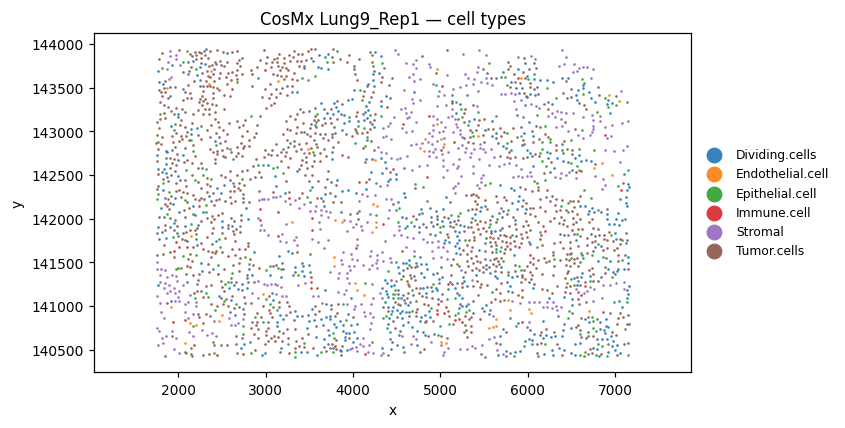

In [4]:
ax = ph.plot_tissue(adata, color='cell_annotation', size=3, alpha=.9)
ax.set_title('CosMx Lung9_Rep1 — cell types')
plt.show()

## 2. `find_near_cells` — the k-nearest-cell search

Returns two aligned frames: the neighbours' **cell types** and their
**distances**, both `n_cells x k`, sorted nearest-first.

| parameter | default | meaning |
|---|---|---|
| `k` | 100 | how many neighbours |
| `target_cell` | `None` | restrict the *query* set |
| `report_cell_id` | `False` | report ids instead of cell types |
| `report_dist` | `True` | also return distances |
| `anno_col` | `'cell_annotation'` | annotation column |
| `basis` | `'spatial'` | `obsm` key for coordinates |
| `tie_break` | `'stable'` | `(distance, index)` ordering — backend-independent |


In [5]:
fnc = ph.find_near_cells(adata, k=100)
print(fnc['cells'].iloc[:5, :5], '\n')
print(fnc['distance'].iloc[:5, :5].round(2))

                nearest_cell_1  nearest_cell_2   nearest_cell_3  \
Lung9_Rep1_5_5     Tumor.cells     Tumor.cells      Tumor.cells   
Lung9_Rep1_5_6     Tumor.cells     Tumor.cells      Tumor.cells   
Lung9_Rep1_5_7     Tumor.cells     Tumor.cells      Tumor.cells   
Lung9_Rep1_5_8         Stromal  Dividing.cells  Epithelial.cell   
Lung9_Rep1_5_14    Tumor.cells     Tumor.cells   Dividing.cells   

                 nearest_cell_4  nearest_cell_5  
Lung9_Rep1_5_5      Tumor.cells     Tumor.cells  
Lung9_Rep1_5_6      Tumor.cells     Tumor.cells  
Lung9_Rep1_5_7   Dividing.cells     Tumor.cells  
Lung9_Rep1_5_8          Stromal  Dividing.cells  
Lung9_Rep1_5_14  Dividing.cells     Tumor.cells   

                 nearest_cell_1  nearest_cell_2  nearest_cell_3  \
Lung9_Rep1_5_5            89.90          124.92          145.38   
Lung9_Rep1_5_6            43.42           77.52           84.97   
Lung9_Rep1_5_7            43.42           48.04           97.00   
Lung9_Rep1_5_8            6

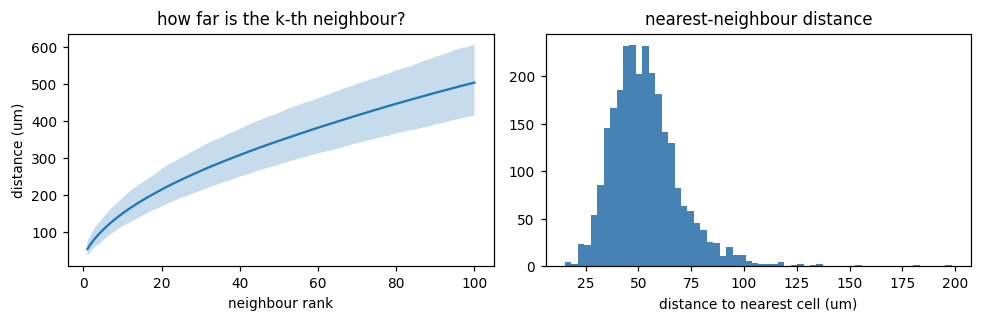

In [6]:
d = fnc['distance'].to_numpy()
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(np.arange(1, 101), d.mean(0), lw=1.5)
ax[0].fill_between(np.arange(1, 101), np.percentile(d, 10, 0), np.percentile(d, 90, 0), alpha=.25)
ax[0].set_xlabel('neighbour rank'); ax[0].set_ylabel('distance (um)')
ax[0].set_title('how far is the k-th neighbour?')
ax[1].hist(d[:, 0], bins=60, color='steelblue')
ax[1].set_xlabel('distance to nearest cell (um)'); ax[1].set_title('nearest-neighbour distance')
fig.tight_layout(); plt.show()

**Choosing k.** k sets the *maximum* spatial extent the method can see. The
softmax then down-weights the far end, so k is a ceiling rather than a hard
radius — this is why hoodscanR is less sensitive to k than a radius-based
counting method is to its radius. k=100 is the upstream default.

## 3. `scan_hoods` — the distance-weighted softmax

$$P_{ij} = \frac{\exp(-d_{ij}^2/\tau)}{\sum_{j'}\exp(-d_{ij'}^2/\tau)}$$

| parameter | default | meaning |
|---|---|---|
| `mode` | `'proximityFocused'` | `'proximityFocused'` fixes τ = median(d²)/5; `'smoothFadeout'` fits it |
| `tau` | `None` | override the bandwidth |
| `t_init` | `None` | starting value for the fit (default median(d²)) |
| `return_tau` | `False` | also return the τ actually used |


In [7]:
pm, tau = ph.scan_hoods(d, verbose=False, return_tau=True)
print(f'tau = {tau:.4f}   (= median(d^2)/5)')
print('rows sum to 1 :', np.allclose(pm.sum(1), 1))
print('shape         :', pm.shape)

tau = 22747.4000   (= median(d^2)/5)
rows sum to 1 : True
shape         : (2661, 100)


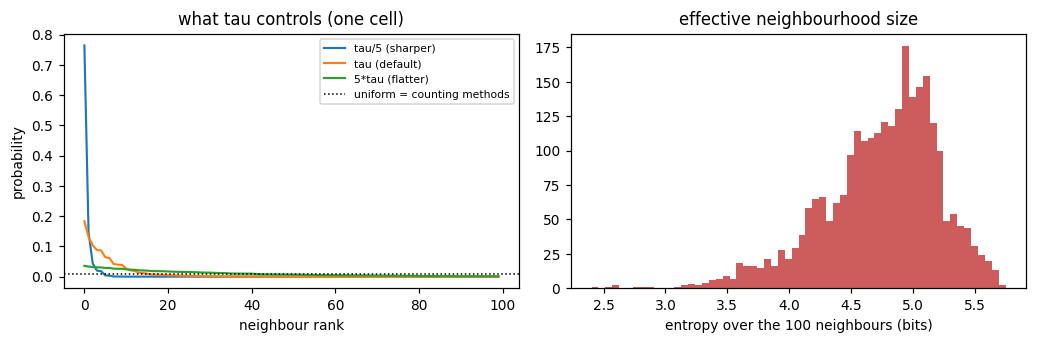

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
for t, lab in [(tau/5, 'tau/5 (sharper)'), (tau, 'tau (default)'), (tau*5, '5*tau (flatter)')]:
    ax[0].plot(ph.soft_max_intl(d[:1], t)[0], lw=1.4, label=lab)
ax[0].axhline(1/100, color='k', ls=':', lw=1, label='uniform = counting methods')
ax[0].set_xlabel('neighbour rank'); ax[0].set_ylabel('probability')
ax[0].set_title('what tau controls (one cell)'); ax[0].legend(fontsize=7)

ent = ph.calculate_metrics(pm)['entropy']
ax[1].hist(ent, bins=60, color='indianred')
ax[1].set_xlabel('entropy over the 100 neighbours (bits)')
ax[1].set_title('effective neighbourhood size')
fig.tight_layout(); plt.show()

### Fitting τ instead of fixing it

`mode='smoothFadeout'` maximises the likelihood of the soft assignment. It is
slower (it runs a BFGS optimisation) so it is usually run on a subsample.

In [9]:
pm_s, tau_s = ph.scan_hoods(d[:500], mode='smoothFadeout', verbose=False, return_tau=True)
print(f'heuristic tau (proximityFocused) = {ph.soft_max_intl.__module__ and tau:.2f}')
print(f'fitted    tau (smoothFadeout)    = {tau_s:.2f}')
print('\nThe fitted tau is larger here, i.e. the likelihood prefers a flatter,')
print('longer-range neighbourhood than the median(d^2)/5 heuristic.')

heuristic tau (proximityFocused) = 22747.40
fitted    tau (smoothFadeout)    = 207757.53

The fitted tau is larger here, i.e. the likelihood prefers a flatter,
longer-range neighbourhood than the median(d^2)/5 heuristic.


## 4. `merge_by_group` — collapse onto cell types

| parameter | default | meaning |
|---|---|---|
| `pm` | — | the `n x k` softmax matrix |
| `group_df` | — | `n x k` labels, **or** a `k x n_types` fuzzy matrix |
| `continuous_annotation` | `False` | treat `group_df` as fuzzy probabilities |


In [10]:
hoods = ph.merge_by_group(pm, fnc['cells'])
hoods.index = adata.obs_names
print('rows still sum to 1 :', np.allclose(hoods.sum(1), 1))
hoods.head().round(4)

rows still sum to 1 : True


,Dividing.cells,Endothelial.cell,Epithelial.cell,Immune.cell,Stromal,Tumor.cells
Lung9_Rep1_5_5,0.0060,0.0004,0.0000,0.0313,0.0000,0.9623
Lung9_Rep1_5_6,0.2067,0.0000,0.0138,0.0000,0.0000,0.7795
Lung9_Rep1_5_7,0.2631,0.0000,0.0202,0.0000,0.0000,0.7167
Lung9_Rep1_5_8,0.2162,0.0000,0.1337,0.0000,0.5802,0.0699
Lung9_Rep1_5_14,0.1747,0.0079,0.0020,0.0000,0.0000,0.8153


### Fuzzy / continuous annotations

If the labels come from deconvolution, feed the probabilities in directly
instead of taking an argmax first — uncertainty then propagates into the
neighbourhood profile. Neither `monkeybread` nor `squidpy` offers this.

In [11]:
rng = np.random.default_rng(0)
fuzzy = rng.random((100, 3)); fuzzy /= fuzzy.sum(1, keepdims=True)
fuzzy = pd.DataFrame(fuzzy, columns=['programme_A', 'programme_B', 'programme_C'])
hoods_fuzzy = ph.merge_by_group(pm, fuzzy, continuous_annotation=True)
print('shape:', hoods_fuzzy.shape, ' rows sum to 1:', np.allclose(hoods_fuzzy.sum(1), 1))
hoods_fuzzy.head().round(4)

shape: (2661, 3)  rows sum to 1: True


,programme_A,programme_B,programme_C
0,0.3763,0.3607,0.2629
1,0.3628,0.3624,0.2747
2,0.3571,0.3697,0.2733
3,0.4507,0.3454,0.2039
4,0.3515,0.3653,0.2832


## 5–6. `merge_hood_adata` and `calc_metrics`

`calc_metrics` writes `entropy` and `perplexity` into `.obs`.

**Perplexity is the number to read.** It is the *effective number of
neighbourhood types* around the cell: 1 = a pure, distinct neighbourhood,
2 = a roughly 50/50 boundary, 6 = maximally mixed here.

In [12]:
ph.merge_hood_adata(adata, hoods)
ph.calc_metrics(adata, pm=hoods.to_numpy())
adata.obs[['entropy', 'perplexity']].describe().round(4)

,entropy,perplexity
count,2661.0000,2661.0000
mean,1.4397,2.8355
std,0.4425,0.8082
min,0.0085,1.0059
25%,1.1514,2.2213
50%,1.4947,2.8181
75%,1.7875,3.4523
max,2.5110,5.7001


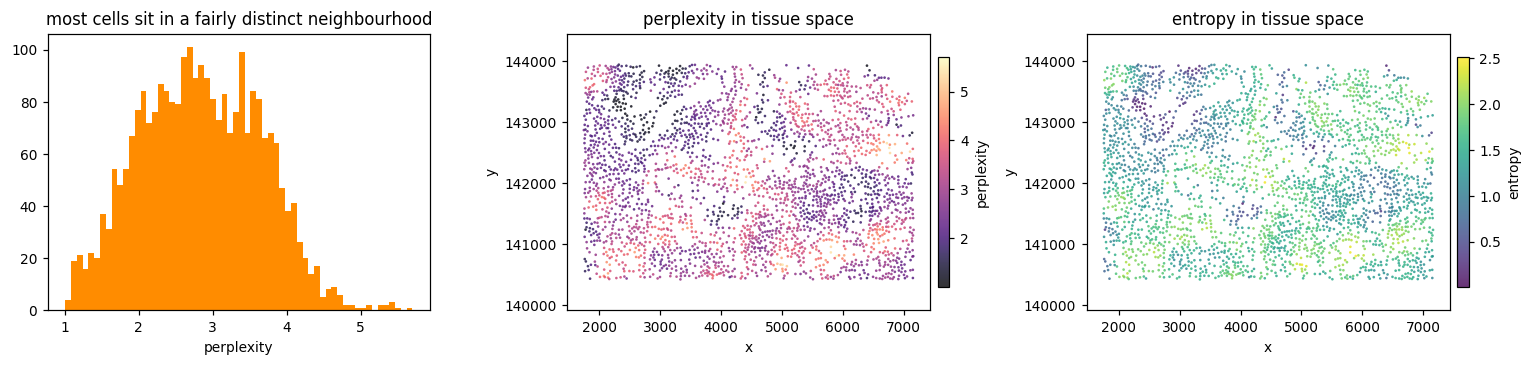

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
ax[0].hist(adata.obs['perplexity'], bins=60, color='darkorange')
ax[0].set_xlabel('perplexity'); ax[0].set_title('most cells sit in a fairly distinct neighbourhood')
ph.plot_tissue(adata, color='perplexity', cmap='magma', size=3, ax=ax[1])
ax[1].set_title('perplexity in tissue space')
ph.plot_tissue(adata, color='entropy', cmap='viridis', size=3, ax=ax[2])
ax[2].set_title('entropy in tissue space')
fig.tight_layout(); plt.show()

/tmp/ipykernel_39107/319258376.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([adata.obs.loc[adata.obs['cell_annotation'] == c, 'perplexity'] for c in order],


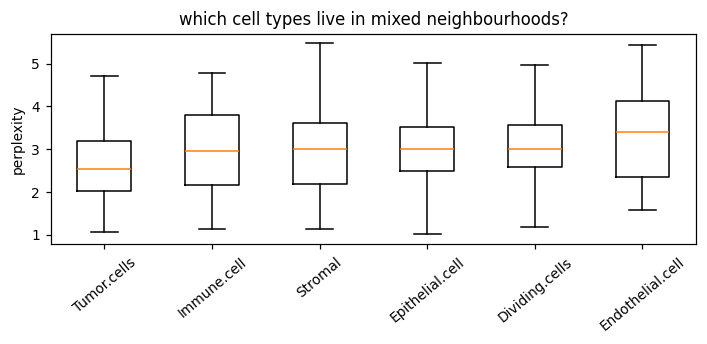

In [14]:
# perplexity per cell type
order = adata.obs.groupby('cell_annotation', observed=True)['perplexity'].median().sort_values().index
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.boxplot([adata.obs.loc[adata.obs['cell_annotation'] == c, 'perplexity'] for c in order],
           labels=list(order), showfliers=False)
ax.set_ylabel('perplexity'); ax.tick_params(axis='x', rotation=40)
ax.set_title('which cell types live in mixed neighbourhoods?')
fig.tight_layout(); plt.show()

Tumour cells sit in the most homogeneous neighbourhoods (low perplexity —
tumour surrounded by tumour); dividing and immune cells are the most mixed.
That is the kind of statement this method exists to make.

## 7. `perplexity_permute` — is this neighbourhood unusually distinct?

Compares each cell's perplexity against the distribution obtained by randomly
re-assigning whole neighbourhood profiles across the tissue.

| parameter | default | meaning |
|---|---|---|
| `n_perm` | 1000 | permutations |
| `seed` | 42 | behaves exactly like R's `set.seed` |
| `exact` | `True` | use the row-permutation identity (exact, ~130x faster) |

A **small** p means unusually *distinct* (low perplexity).

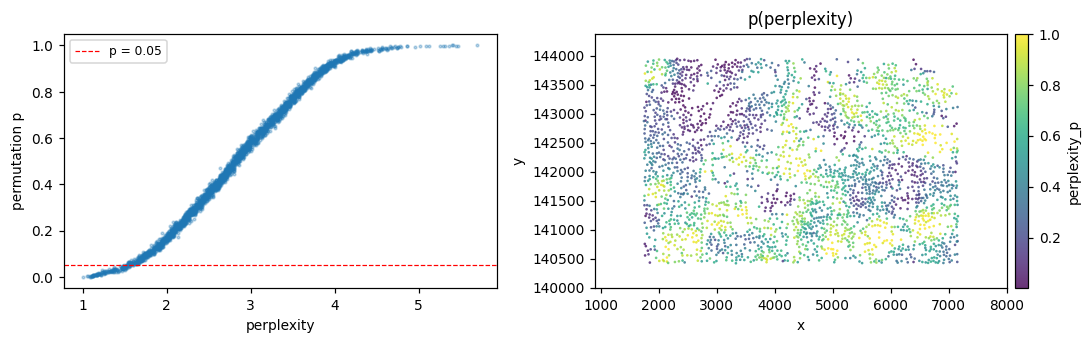

129 cells with p < 0.05 (4.8%)


In [15]:
ph.perplexity_permute(adata, pm=hoods.to_numpy(), n_perm=1000, seed=42)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].scatter(adata.obs['perplexity'], adata.obs['perplexity_p'], s=3, alpha=.3)
ax[0].axhline(0.05, color='r', ls='--', lw=.8, label='p = 0.05'); ax[0].legend(fontsize=8)
ax[0].set_xlabel('perplexity'); ax[0].set_ylabel('permutation p')
ph.plot_tissue(adata, color='perplexity_p', cmap='viridis', size=3, ax=ax[1])
ax[1].set_title('p(perplexity)')
fig.tight_layout(); plt.show()
print(f"{(adata.obs['perplexity_p'] < 0.05).sum()} cells with p < 0.05 "
      f"({(adata.obs['perplexity_p'] < 0.05).mean():.1%})")

## 8. `clust_by_hood` — neighbourhood-based clustering

k-means (**Hartigan–Wong**, R's default — ported here because scikit-learn only
ships Lloyd/Elkan) on the probability profiles.

| parameter | default | meaning |
|---|---|---|
| `k` | `0` → `2**n_types - 1` | number of clusters |
| `nstart` | 5 | random restarts |
| `iter_max` | 1000 | transfer sweeps |
| `seed` | 42 | matches R's `set.seed` |


clusters
1     218
10    325
2     329
3     319
4     201
5     423
6     169
7     221
8     179
9     277
Name: count, dtype: int64


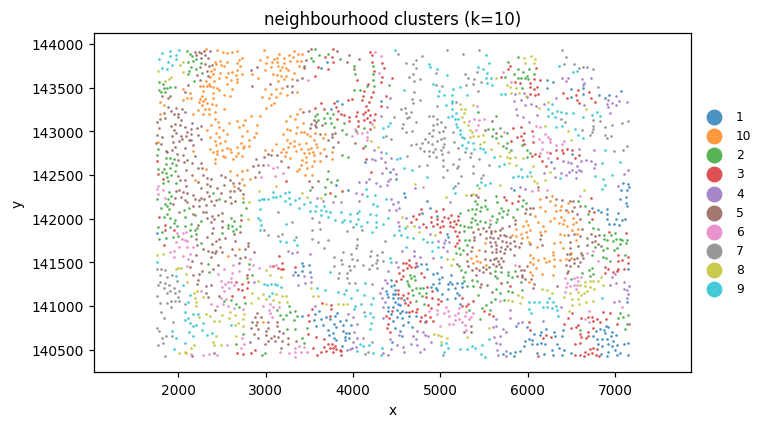

In [16]:
ph.clust_by_hood(adata, pm_cols=list(hoods.columns), k=10, seed=42)
print(adata.obs['clusters'].value_counts().sort_index())
ax = ph.plot_tissue(adata, color='clusters', size=3)
ax.set_title('neighbourhood clusters (k=10)')
plt.show()

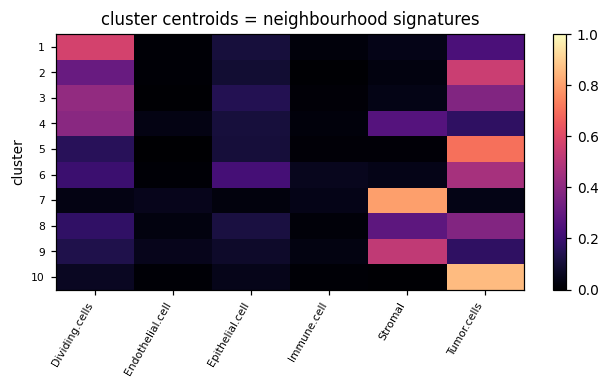

,Dividing.cells,Endothelial.cell,Epithelial.cell,Immune.cell,Stromal,Tumor.cells
1,0.571,0.008,0.112,0.023,0.044,0.242
2,0.312,0.009,0.095,0.007,0.029,0.547
3,0.416,0.007,0.146,0.014,0.042,0.374
4,0.394,0.037,0.111,0.022,0.262,0.174
5,0.160,0.004,0.108,0.015,0.013,0.700
6,0.200,0.009,0.224,0.058,0.045,0.463
7,0.038,0.052,0.026,0.044,0.798,0.042
8,0.176,0.029,0.119,0.018,0.283,0.375
9,0.135,0.053,0.082,0.032,0.524,0.175
10,0.065,0.011,0.049,0.012,0.005,0.858


In [17]:
cent = pd.DataFrame(adata.uns['hoodscanr']['centroids'], columns=hoods.columns,
                    index=[str(i+1) for i in range(10)])
fig, ax = plt.subplots(figsize=(6, 3.6))
im = ax.imshow(cent.to_numpy(), cmap='magma', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(6)); ax.set_xticklabels(cent.columns, rotation=60, ha='right', fontsize=7)
ax.set_yticks(range(10)); ax.set_yticklabels(cent.index, fontsize=7)
ax.set_ylabel('cluster'); ax.set_title('cluster centroids = neighbourhood signatures')
fig.colorbar(im, ax=ax); fig.tight_layout(); plt.show()
cent.round(3)

## 9. Plotting

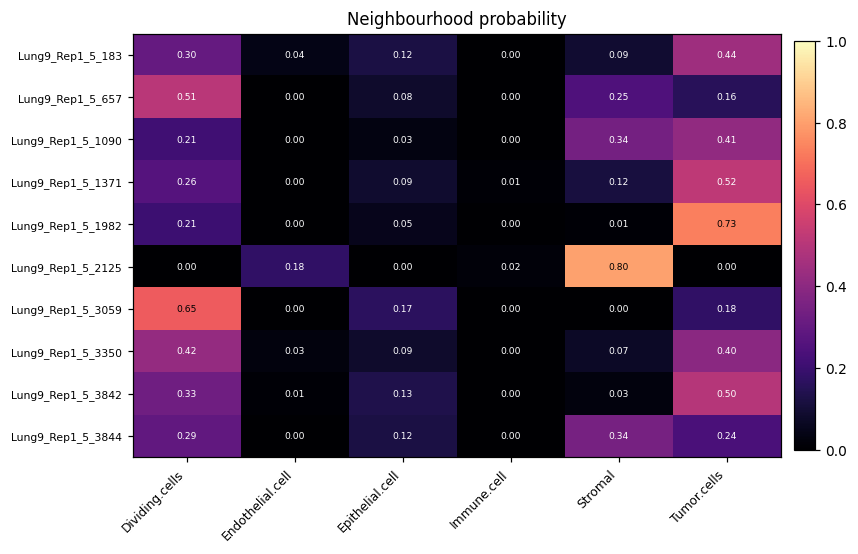

In [18]:
ph.plot_hood_mat(hoods, n=10, seed=1)
plt.show()

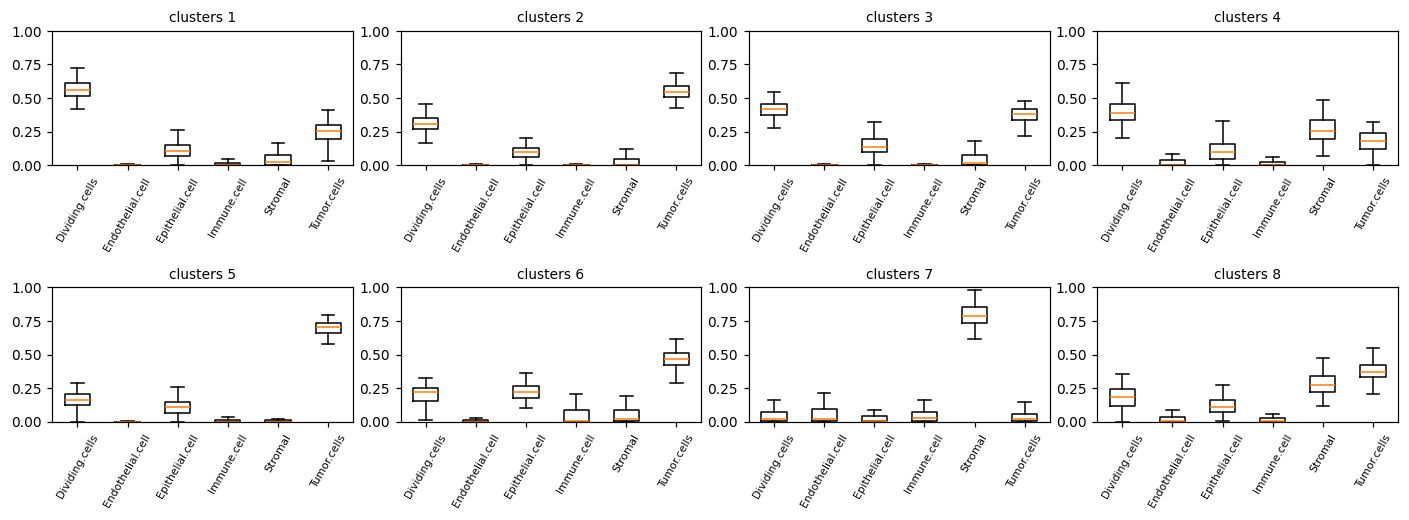

In [19]:
ph.plot_prob_dist(adata, pm_cols=list(hoods.columns), by_cluster=True,
                  plot_all=True, show_clusters=[str(i) for i in range(1, 9)])
plt.show()

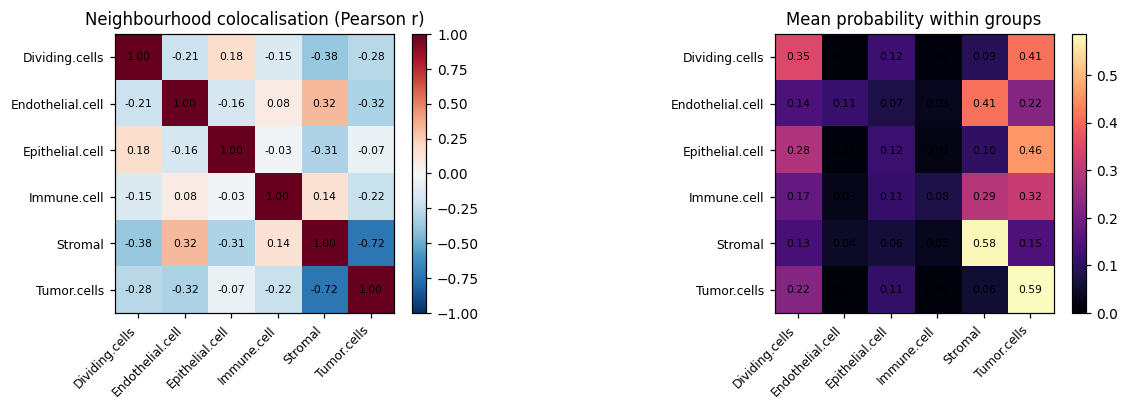

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ph.plot_colocal(adata, ax=ax[0])
ph.plot_colocal(adata, self_cor=False, by_group='cell_annotation', cmap='magma', ax=ax[1])
fig.tight_layout(); plt.show()

The left panel is the colocalisation analysis: endothelial and stromal
neighbourhoods co-occur, as do epithelial and dividing — reproducing the
observation in the upstream vignette.

## 10. The class API

Same computation, chainable, results accumulate in `hs.adata`.

In [21]:
hs = (ph.HoodScanR(ph.load_spe_test(), anno_col='cell_annotation')
        .find_near_cells(k=100)
        .scan_hoods()
        .merge_by_group()
        .calc_metrics()
        .clust_by_hood(k=10))
print(hs)
hs.adata.obs[['cell_annotation', 'entropy', 'perplexity', 'clusters']].head()

HoodScanR(n_cells=2661, tau=22747.4, n_hoods=6)


,cell_annotation,entropy,perplexity,clusters
Lung9_Rep1_5_5,Tumor.cells,0.258455,1.196197,10
Lung9_Rep1_5_6,Tumor.cells,0.835702,1.784725,5
Lung9_Rep1_5_7,Tumor.cells,0.964758,1.951736,5
Lung9_Rep1_5_8,Stromal,1.589795,3.010065,9
Lung9_Rep1_5_14,Tumor.cells,0.753675,1.686083,10


In [22]:
# or in one call
hs2 = ph.HoodScanR(ph.load_spe_test(), anno_col='cell_annotation').run(k=100, n_clusters=10)
print(hs2)

HoodScanR(n_cells=2661, tau=22747.4, n_hoods=6)


## 11. Pitfalls

1. **`.obs` gets one column per cell type.** `merge_hood_adata` writes the
   probability matrix into `.obs` (mirroring R's `colData`) *and* into
   `.obsm['hoods']`. If a cell type shares a name with an existing `.obs`
   column it will be overwritten. The column names are recorded in
   `adata.uns['hoodscanr']['pm_cols']`, so downstream calls do not need
   `pm_cols` spelled out.

2. **Perplexity is bounded by the number of cell types**, not by k. With 6 cell
   types it lies in [1, 6]. Comparing perplexity across datasets with different
   annotation granularity is meaningless.

3. **`k` is a ceiling, not a radius.** Increasing k mostly adds heavily
   down-weighted neighbours. If you want a hard spatial cut-off, use
   `squidpy`'s radius graph instead.

4. **`smoothFadeout` is not free.** It runs a BFGS fit; run it on a subsample
   and reuse the τ via `scan_hoods(d, tau=fitted_tau)`.

5. **Exact-distance ties at the k-th neighbour.** On a regular grid or with
   duplicated coordinates, several cells can be exactly equidistant at the
   boundary and which one is admitted is arbitrary. `tie_break='stable'`
   (the default) makes *this* package deterministic;
   `find_near_cells(..., warn_boundary_ties=True)` reports affected cells.

6. **Cluster labels are 1-based strings**, matching R's `clustByHood`.

7. **`numba` is optional but worth it** — `pip install pyhoodscanr[speed]`.
   Results are identical either way; the permutation test is ~130x slower
   without it.


In [23]:
fnc_warn = ph.find_near_cells(adata, k=100, warn_boundary_ties=True)
print('done — see the warning above if any boundary ties were found')

done — see the warning above if any boundary ties were found


/tmp/ipykernel_39107/3734226869.py:1: UserWarning: 4 cell(s) have an exact distance tie at the k-th neighbour; which of the tied cells enters the neighbourhood is arbitrary (R's ANN and scikit-learn may disagree). First few: ['Lung9_Rep1_5_1104', 'Lung9_Rep1_5_1974', 'Lung9_Rep1_5_2439', 'Lung9_Rep1_5_3448']
  fnc_warn = ph.find_near_cells(adata, k=100, warn_boundary_ties=True)
